## word2vec

### 추론 기반 기법과 신경망
* 단어를 벡터로 표현하는 방법 중 성공적인 기법
    * 통계 기반 기법
    * 추론 기반 기법  
    => 배경에는 모두 분포 가설이 있음

#### 통계 기반 기법의 문제점
* 단어의 동시발생 행렬을 만들고 그 행렬에 SVD를 적용하여 밀집벡터를 얻음  
=> 대규모 말뭉치를 다룰 때 문제가 발생
* 대규모 말뭉치에서 SVD를 적용하는 일은 비현실적
* 통계 기반 기법은 다 1회의 처리만에 단어의 분산 표현을 얻음
* 추론 기반 기법에서는, 신경망을 이용하는 경우는 미니배치로 학습하는 것이 일반적
* 미니배치 학습에서는 신경망이 한 번에 소량의 학습 샘플씩 반복해서 가중치를 갱신해감

#### 추론 기반 기법 개요
* 추론: 주변 단어가 주어졌을 때 빈 칸에 무슨 단어가 들어가는지를 추측하는 작업
* 추론 문제를 반복해서 풀면서 단어의 출현 패턴을 학습
* 추론 기반 기법에는 모델이 있으며 모델로 신경망을 사용
* 모델은 맥락 정보를 입력받아 각 단어의 출현 확률을 출력
* 말뭉치로 모델이 올바른 추측을 내놓도록 학습  
=> 그 학습 결과로 단어의 분산 표현을 얻는 것이 추론 기반 기법의 전체 그림

#### 신경망에서의 단어 처리
* 신경망으로 단어를 처리
* 단어를 고정 길이의 벡터로 변환  
    => 원핫 표현(또는 원핫 벡터)로 변환
    * 원핫 표현: 벡터의 원소 중 하나만 1이고 나머지는 모두 0

* 단어를 고정 길이 벡터로 변환하면 신경망의 입력층은 뉴런의 수를 고정할 수 있음
* 신경망을 구성하는 계층들은 벡터를 처리할 수 있음  
=> 단어를 신경망으로 처리할 수 있음
* 가중치가 존재하여, 입력층 뉴런과의 가중합이 은닉층 뉴런이 됨

In [1]:
# 완전연결계층에 의한 변환
import numpy as np

c = np.array([1, 0, 0, 0, 0, 0, 0]) # 입력
W = np.random.rand(7, 3) # 가중치
h = np.matmul(c, W) # 중간노드

print(h)

[0.73881714 0.18794158 0.48951116]


* 단어 ID가 0인 단어를 원핫 표현으로 표현한 다음 완전연결계층을 통과시켜 변환
* 완전연결계층의 계산은 행렬 곱으로 수행할 수 있으며, 행렬 곱은 np.matmul()로 해결
* c와 W의 행렬 곱은 가중치의 행벡터 하나를 뽑아낸 것과 동일

### 단순한 word2vec

#### CBOW 모델의 추론 처리
* CBOW 모델은 맥락으로부터 타깃을 추출하는 용도의 신경망 (타깃은 중앙 단어)
* 모델의 입력은 맥락이며 맥락을 원핫 표현으로 변환


* 입력층이 2개, 은닉층을 거쳐 출력층에 도달
    * 맥락에 포함시킬 단어가 N개면 입력층도 N개
* 두 입력층에서 은닉층으로의 변환은 똑같은 완전연결계층(가중치 $W_{in}$)이 처리
* 은닉층에서 출력층 뉴런으로의 변환은 다른 완전연결계층(가중치 $w_{out}$)이 처리
* 은닉층의 뉴런은 입력층의 완전연결계층에 의해 변환된 값이 되며, 입력층이 여러 개면 전체를 평균
    * 완전연결계층에 의한 첫 번째 입력층이 $h_1$으로 변환되고, 두 번째 입력층이 $h_2$로 변환되었다면 은닉층 뉴런은 $\frac{1}{2} (h_1 + h_2)$
* 출력층의 뉴런 하나하나가 각 단어에 대응하며 각 단어의 점수를 뜻하며 높을수록 대응 단어의 출현 확률이 높아짐
    * 점수: 확률로 해석되기 전의 값
    * 소프트맥스로 확률을 얻을 수 있음

* 가중치 $W_{in}$의 각 행에는 해당 단어의 분산 표현이 담겨 있음
* 학습을 진행할수록 맥락에서 출현하는 단어를 잘 추측하는 방향으로 분산 표현들이 갱신

In [1]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul


# 샘플 맥락 데이터
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 가중치 초기화
W_in = np.random.randn(7, 3)
W_out = np.random.randn(3, 7)

# 계층 생성
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 순전파
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)
print(s)


[[-0.75609555 -0.49594739  1.69349688 -1.09033043 -1.78850127 -0.96271717
  -1.21145358]]


* 입력층의 MatMul 계층은 가중치 $W_{in}$을 공유

#### CBOW 모델의 학습
* 점수에 소프트맥스 함수를 적용하면 확률을 얻을 수 있음
* 확률은 맥락이 주어졌을 때 중앙에 어떤 단어가 출현하는지를 나타냄
* CBOW 모델의 학습에서는 올바른 예측을 할 수 있도록 가중치를 조정하는 일을 함
* 그 결과 가중치 $W_{in}$에 단어의 출현 패턴을 파악한 벡터가 학습
* CBOW 모델은 말뭉치가 다르면 학습 후 얻게 되는 단어의 분산 표현도 달라짐

* CBOW 모델의 학습 시 신경망 구성
    * CBOW 모델에 Softmax 계층, Cross Entropy Error 계층을 추가  
=> CBOW 모델의 손실을 구하는 계산의 흐름이자 신경망의 순방향 전파

#### word2vec의 가중치와 분산 표현
* 두 가지 가중치
    * 입력 측 완전연결계층의 가중치($W_{in}$): 각 행이 각 단어의 분산 표현
    * 출력 측 완전연결계층의 가중치($W_{out}$): 단어의 의미가 인코딩된 벡터가 저장

* word2vec(특히 skip-gram) 모델에서는 입력 측의 가중치만 이용하는 것이 가장 대중적인 선택
* 많은 연구에서 출력 측 가중치는 버리고 입력 측 가중치 $W_{in}$만 최종 단어의 분산 표현으로서 이용

### 학습 데이터 준비

#### 맥락과 타깃
* word2vec에서 이용하는 신경망의 입력은 맥락
* 정답 레이블은 맥락에 둘러싸인 중앙의 단어, 타깃  
=> 신경망에 맥락을 입력했을 때 타깃이 출현할 확률을 높이는 것

In [4]:
import sys
sys.path.append('..')
from common.util import preprocess

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)

print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [9]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus) - window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

contexts, target = create_contexts_target(corpus)
print(contexts)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


#### 원핫 표현으로 변환

In [11]:
import sys
sys.path.append('..')
from common.util import preprocess, create_contexts_target, convert_one_hot

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

print(target)
print(contexts)

[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]
[[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]


### CBOW 모델 구현

In [18]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss


class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모은다.
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장한다.
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

* 초기화 메서드는 인수로 어휘 수와 은닉층의 뉴런 수를 받음
* 가중치 초기화 부분에서는 가중치를 2개 생성 (랜덤, float32)
* 필요한 계층을 생성
* 신경망에서 사용되는 매개변수와 기울기를 인스턴스 변수와 리스트에 모음

#### 학습 코드 구현
* 학습 데이터를 준비해 신경망에 입력한 다음, 기울기를 구하고 가중치 매개변수를 순서대로 갱신

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

C:\Users\기현\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\기현\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\기현\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\기현\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


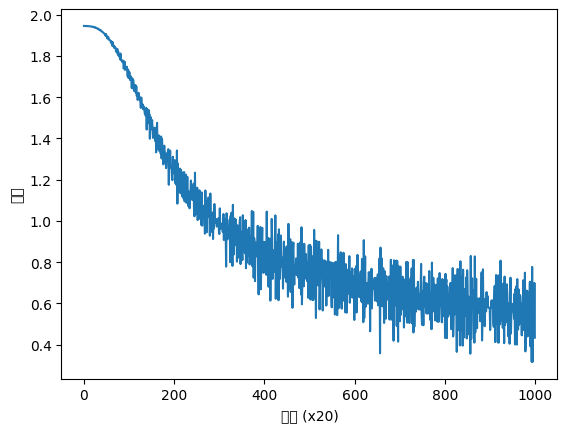

you [ 1.0245894  1.01396   -1.2893739 -0.9898234 -1.4054916]
say [-1.1608413  -1.1443436  -0.05684521  1.1780983   1.2228118 ]
goodbye [ 0.9270965   0.9984898  -0.64502054 -0.96337754 -0.2775903 ]
and [-1.0326189 -1.0282712  1.8546354  0.9704343  1.1416453]
i [ 0.9608527   0.98461556 -0.6492872  -0.96357435 -0.27081877]
hello [ 1.0336883  1.0089082 -1.2919812 -1.0056067 -1.3951035]
. [-0.95073    -0.95461714 -1.6274749   1.0182221   0.92274433]


In [19]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot


window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

* 말뭉치가 작기 때문에 좋은 결과를 얻을 수 없음
* 말뭉치가 커지면 결과가 좋아지지만 처리 속도 면에서 문제가 생김  
=> 개선이 필요

### word2vec 보충

#### CBOW 모델과 확률
* CBOW 모델을 확률 표기법으로 기술
    * 말뭉치를 $w_1, w_2, ..., w_T$ 처럼 단어 시퀀스로 표기
    * t번째 단어에 대해 윈도우 크기가 1인 맥락을 고려
$$
w_1 w_2 ... w_{t-1} w_t w_{t + 1} ... w_{T - 1} w_T
$$

* 맥락으로 $w_{t-1}$, $w_{t+1}$이 주어졌을 떼 타깃이 $w_t$가 될 확률
$$
P(w_t | w_{t-1}, w_{t+1})
$$
* CBOW는 이 식을 모델링

* 손실 함수도 표현 가능
* 교차 엔트로피 오차를 이용하면
$$
L = -log P(w_t | w_{t-1}, w_{t+1})
$$  
=> 음의 로그 가능도

* 말뭉치 전체로 확장하면
$$
L = -\frac{1}{T} \sum_{t=1}^{T} log P(w_t | w_{t-1}, w_{t+1})
$$  

#### skip-gram 모델
* skip-gram은 CBOW에서 다루는 맥락과 타깃을 역전시킨 모델
* CBOW 모델은 여러 맥락으로부터 중앙의 단어를 추측
* skip-gram 모델은 중앙의 단어로부터 주변의 여러 단어를 추측

* skip-gram 모델의 입력층은 하나, 출력층은 맥락의 수만큼 존재
* 각 출력층에서는 개별적으로 손실을 구하고 개별 손실들을 모두 더한 값을 최종 손실로 함
* skip-gram 모델의 확률 표기
$$
P(w_{t-1}, w_{t+1} | w_t)
$$

* skip-gram 모델에서 조건부 독립을 가정하면
$$
P(w_{t-1}, w_{t+1} | w_t) = P(w_{t-1} | w_t) P(w_{t+1} | w_t)
$$

* 교차 엔트로피 오차에 적용해 skip-gram 모델의 손실 함수를 유도하면
$$
L = -log P(w_{t-1}, w_{t+1} | w_t) \\ 
= -log P(w_{t-1} | w_t) P(w_{t+1} | w_t) \\
= -(log P(w_{t-1} | w_t) + log P(w_{t+1} | w_t))
$$  

* 말뭉치 전체로 확장하면
$$
L = -\frac{1}{T} \sum_{t=1}^{T} (log P(w_{t-1} | w_t) + log P(w_{t+1} | w_t))
$$

* 말뭉치가 커질수록 저빈도 단어나 유추 문제의 성능 면에서 skip-gram이 더 뛰어난 경향이 있음
* 학습 속도 면에서는 CBOW 모델이 빠름

#### 통계 기반 vs 추론 기반
* 통계 기반 기법은 말뭉치의 전체 통계로부터 1회 학습해 단어의 분산 표현을 획득
* 추론 기반 기법에서는 말뭉치를 일부분씩 여러 번 보면서 학습(미니배치 학습)

* 어휘에 추가할 새 단어가 생겨서 단어의 분산 표현을 갱신해야 하는 경우
    * 통계 기반 기법은 처음부터 계산을 다시 해야 함
    * 추론 기반 기법은 매개변수를 다시 학습할 수 있음
        => 기존에 학습한 경험을 해치지 않으면서 단어의 분산 표현을 효율적으로 갱신할 수 있음

* 분산 표현의 성격이나 정밀도 측면
    * 통계 기반 기법에서는 주로 단어의 유사성이 인코딩
    * word2vec(특히 skip-gram)에서는 단어의 유사성은 물론, 한층 복잡한 단어 사이의 패턴까지도 파악되어 인코딩

* 하지만 실제로 단어의 유사성을 정량 평가해본 결과, 의외로 추론 기반과 통계 기반 기법의 우열을 가릴 수 없었음
* 또한 통계 기반 기법과 추론 기반 기법은 서로 관련되어 있음
* word2vec 이후 두 기법을 융합한 GloVe 기법이 나타남
    * GloVe의 기본 아이디어는 말뭉치 전체의 통계 정보를 손실 함수에 도입해 미니배치 학습을 하는 것